In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
import mlflow.sklearn
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
#import xgboost as xgb
from sklearn.model_selection import cross_val_score, RandomizedSearchCV
from scipy.stats import randint, uniform, bootstrap
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error, root_mean_squared_error
from contextlib import nullcontext
import yaml
import os

In [51]:
mlflow_tracking_uri = "http://localhost:5555"
data = pd.read_csv("/Users/claudiogonzalezarriaga/Documents/Progra_Tec/Octavo/MLops/SuCasita/data/processed/sacramento_train.csv")

In [52]:
data.head()

,baths__ratio,log__sqft,beds__ratio,remainder__longitude,remainder__latitude,price
0,-0.111463,1.083250,-0.783075,0.288278,-0.940434,273750
1,-0.643414,-1.287744,0.100584,0.015612,0.562460,150454
2,1.239091,0.298223,0.358653,0.570578,0.591600,195000
3,0.155185,0.907618,-0.557656,0.429678,1.340332,315000
4,2.650633,-1.342777,0.189081,-0.661673,-0.719974,173056


In [53]:
X_train = data.drop(columns=["price"])
y_train = data["price"].copy()

In [54]:
if mlflow_tracking_uri:
    mlflow.set_tracking_uri(mlflow_tracking_uri)
    mlflow.set_experiment("su-casita-pred")

In [55]:
models = {"LinearRegression": LinearRegression(),
          "KNeighbors": KNeighborsRegressor(),
          "RandomForest": RandomForestRegressor(),
          "GradientBoosting": GradientBoostingRegressor()
          #"XGBoost": xgb.XGBRegressor(objective = "reg:squarederror"),
          }

In [56]:
results = []
for name, model in models.items():
    print(f"Corriendo modelo {name}")
    scores = cross_val_score(estimator = model,
                        cv = 10,
                        X = X_train,
                        y = y_train,
                        scoring = "neg_mean_absolute_percentage_error")
    results.append((name, scores.mean(), scores.std()))

Corriendo modelo LinearRegression
Corriendo modelo KNeighbors
Corriendo modelo RandomForest
Corriendo modelo GradientBoosting


In [57]:
results = pd.DataFrame(results,
                     columns = ["model", "mean_mape", "std_mape"]).sort_values(by = "mean_mape",
                                                                               ascending = False)
results
                            

,model,mean_mape,std_mape
2,RandomForest,-0.265940,0.028656
3,GradientBoosting,-0.274711,0.032186
1,KNeighbors,-0.276029,0.037581
0,LinearRegression,-0.285685,0.039210


In [58]:
models = {"RandomForest": RandomForestRegressor(),
          "GradientBoosting": GradientBoostingRegressor(),
          "KNeighbors": KNeighborsRegressor()}

In [59]:
model_distribs = {"RandomForest": {"n_estimators": randint(low = 100, high = 1000),
                                   "max_depth": randint(low = 3, high = 10)},
                  "GradientBoosting": {"n_estimators": randint(low = 100, high = 250),
                                       "learning_rate": uniform(loc = 0.01, scale = 0.5),
                                       "max_depth": randint(low = 3, high = 10)},
                  "KNeighbors": {"n_neighbors": randint(low = 2, high = 50)}}

In [95]:
def tune_model(name, model, distrib, X_train, y_train):
    '''
    Afina los hiperparámetros de un modelo
    mediante cross-validation y random search.

    Input
    -----
    name: str
        Nombre del modelo.
    model: instance
        Instancia del modelo.
    distrib: dict
        Diccionario con los hiperparámetros a optimizar.
    X_train: pd.DataFrame
        Features del conjunto de entrenamiento.
    y_train: pd.DataFrame, pd.Series
        Conjunto de targets de entrenamiento.
    
    Output
    ------
    dict
        Diccionario con el nombre del modelo, instancia
        del modelo optimizado, parámetros del modelo,
        score del modelo optimizado por cross-validation,
        métricas medidas sobre el training set.
    '''

    ## Inicializamos el random search
    rnd_search = RandomizedSearchCV(estimator = model,
                            param_distributions = distrib,
                            n_iter = 50,
                            cv = 10,
                            scoring = "neg_mean_absolute_percentage_error",
                            random_state = 42,
                            n_jobs = -1)

    ## Ejecutamos el random search
    rnd_search.fit(X_train, y_train)

    ## Extraemos el modelo, parámetros y score
    best_model = rnd_search.best_estimator_
    best_params = rnd_search.best_params_
    best_score = rnd_search.best_score_

    ## Obtenemos las predicciones
    y_pred = best_model.predict(X_train)

    ## Calculamos el MAPE, MAE y RMSE
    mape = mean_absolute_percentage_error(y_train, y_pred)
    mae = mean_absolute_error(y_train, y_pred)
    rmse = root_mean_squared_error(y_train, y_pred)

    return {"name": name,
            "model": best_model,
            "params": best_params,
            "score": best_score,
            "mape": mape,
            "mae": mae,
            "rmse": rmse}

In [96]:
results = []

with mlflow.start_run(run_name = "model_comparison") if mlflow_tracking_uri else nullcontext():
    for name, model in models.items():
        print(f"Tuneando {name}...")
        with mlflow.start_run(run_name = name, nested = True) if mlflow_tracking_uri else nullcontext():
            ## Afinamos el modelo y guardamos los resultados
            evaluation = tune_model(name, model, model_distribs[name], X_train, y_train)
            results.append(evaluation)

            ## Registramos los parámetros,
            ## métricas y modelos en MLflow        
            if mlflow_tracking_uri:
                mlflow.log_params(evaluation["params"])
                mlflow.log_metrics({"mape": evaluation["mape"],
                                    "mae": evaluation["mae"],
                                    "rmse": evaluation["rmse"]})
                #mlflow.sklearn.log_model(evaluation["model"],
                #                         artifact_path = name.lower().replace(" ", "_"))

Tuneando RandomForest...
🏃 View run RandomForest at: http://localhost:5555/#/experiments/1/runs/d8d3fc2e85874a5f9355cb40002df247
🧪 View experiment at: http://localhost:5555/#/experiments/1
Tuneando GradientBoosting...
🏃 View run GradientBoosting at: http://localhost:5555/#/experiments/1/runs/bc404d12d21d443da765faec1ad8fe9e
🧪 View experiment at: http://localhost:5555/#/experiments/1
Tuneando KNeighbors...
🏃 View run KNeighbors at: http://localhost:5555/#/experiments/1/runs/fa3c20bbbc464f43b2ca686d6e3f350d
🧪 View experiment at: http://localhost:5555/#/experiments/1
🏃 View run model_comparison at: http://localhost:5555/#/experiments/1/runs/d6c2e9943e0549ea9e4eaf187a1e3420
🧪 View experiment at: http://localhost:5555/#/experiments/1


In [97]:
def plot_model_metrics(results, metric = "mape", ax = None):
    names = [results[i]["name"] for i in range(len(results))]
    values = [results[i][metric] for i in range(len(results))]

    if ax is None:
        fig, ax = plt.subplots(figsize = (10, 6))

    sns.barplot(x = names, y = values, color = "dodgerblue", ax = ax)
    ax.set_title(f"Comparación de modelos por {metric.upper()}")
    ax.set_xlabel("Modelo")
    ax.set_ylabel(metric.upper())
    ax.grid(True)



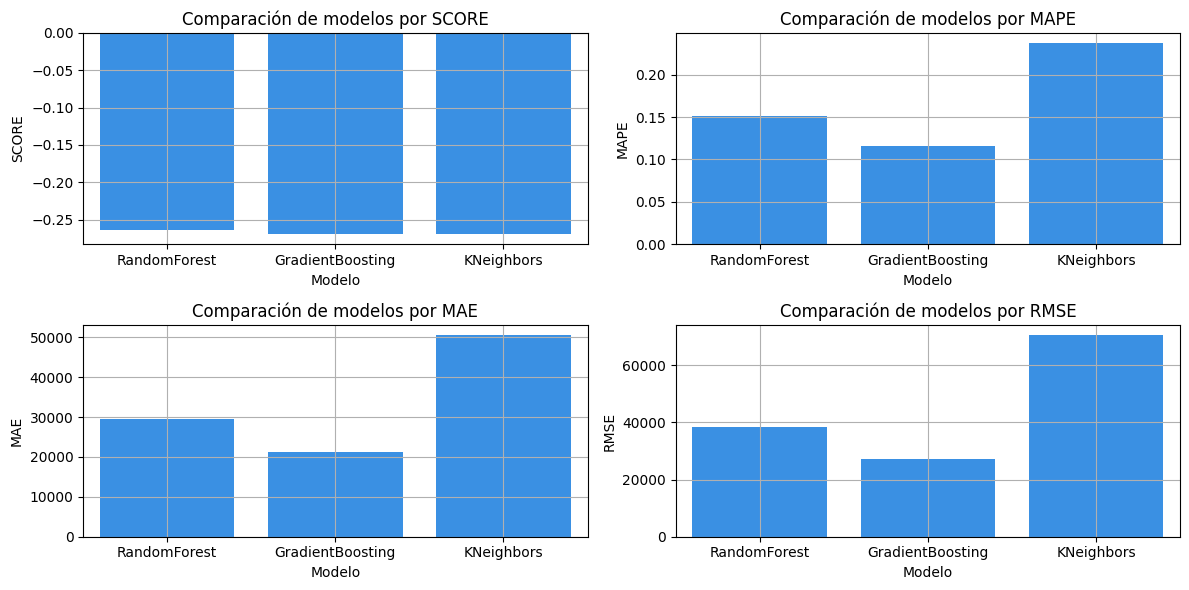

In [98]:
metrics = ["score", "mape", "mae", "rmse"]

fig, axes = plt.subplots(nrows = 2, ncols = 2, figsize = (12, 6))
axes = axes.flatten()

for ax, metric in zip(axes, metrics):
    plot_model_metrics(results, metric, ax)
plt.tight_layout()
plt.show()

In [99]:
test = pd.read_csv("/Users/claudiogonzalezarriaga/Documents/Progra_Tec/Octavo/MLops/SuCasita/data/processed/sacramento_test.csv")

In [100]:
X_test = test.drop(columns = ["price"])
y_test = test["price"].copy()

In [101]:
# Extraemos el mejor modelo de nuestros resultados.
final_model = results[0]["model"]

In [102]:
y_pred = final_model.predict(X_test)

In [103]:
mape = mean_absolute_percentage_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)

In [104]:
def mape_(absolute_ratios):
    '''
    Calcula el MAPE.

    Input
    -----
    absolute_ratios: np.array
        Arreglo con los ratios absolutos
    
    Output
    ------
    float
        MAPE.
    '''

    return np.mean(absolute_ratios)

In [105]:
confidence = .95
absolute_ratios = np.abs((y_test - y_pred)/y_test)
boot_result = bootstrap(data = [absolute_ratios],
                        statistic = mape_,
                        confidence_level = confidence,
                        random_state = 42)

In [106]:
mape_lower, mape_upper = boot_result.confidence_interval
(round(mape_lower, 4), round(mape_upper, 4))

(np.float64(0.2475), np.float64(0.3286))

In [107]:
best = max(results, key = lambda x: x["score"])

In [108]:
best_model_name = best["name"]
best_model = best["model"]
best_params = best_model.get_params()

In [109]:
model_config = {"model": {"name": "su_casita_model",
                          "best_model": best_model_name,
                          "parameters": best_params,
                          "mape": mape,
                          "mae": mae,
                          "rmse": rmse,
                          "target_variable": "price"}}

In [110]:
config_path = "../configs/model_config.yaml"
os.makedirs(os.path.dirname(config_path), exist_ok = True)
with open(config_path, "w") as f:
    yaml.dump(model_config, f)

In [111]:
results

[{'name': 'RandomForest',
  'model': RandomForestRegressor(max_depth=9, n_estimators=781),
  'params': {'max_depth': 9, 'n_estimators': 781},
  'score': np.float64(-0.2644418016110791),
  'mape': 0.15105656692175543,
  'mae': 29576.98694896057,
  'rmse': 38486.31018642944},
 {'name': 'GradientBoosting',
  'model': GradientBoostingRegressor(learning_rate=np.float64(0.03820578951355013),
                            max_depth=6, n_estimators=137),
  'params': {'learning_rate': np.float64(0.03820578951355013),
   'max_depth': 6,
   'n_estimators': 137},
  'score': np.float64(-0.26955760951773966),
  'mape': 0.11604886778549181,
  'mae': 21164.267101136782,
  'rmse': 27212.677760889266},
 {'name': 'KNeighbors',
  'model': KNeighborsRegressor(n_neighbors=9),
  'params': {'n_neighbors': 9},
  'score': np.float64(-0.2687858123439998),
  'mape': 0.23759961518320913,
  'mae': 50470.08926437959,
  'rmse': 70477.51684617638}]